In [10]:
import pandas as pd

df = pd.read_csv("../data/sme_gym_sales_2015_2025-1.csv")

In [11]:
quality_check = pd.DataFrame({
    "Metric": ["Missing Values", "Duplicate Rows"],
    "Value": [
        df.isna().sum().sum(),
        df.duplicated().sum()
    ]
})

display(quality_check)

df = df.drop_duplicates().reset_index(drop=True)

,Metric,Value
0,Missing Values,80
1,Duplicate Rows,15


KPIs and Trend

In [12]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

jan_2015 = df[
    (df["transaction_date"] >= "2015-01-01") &
    (df["transaction_date"] < "2015-02-01")
]

dec_2025 = df[
    (df["transaction_date"] >= "2025-12-01") &
    (df["transaction_date"] < "2026-01-01")
]

baseline = jan_2015["gross_revenue_gbp"].sum()
current = dec_2025["gross_revenue_gbp"].sum()
change = (current - baseline) / baseline * 100

display(pd.DataFrame({
    "Metric": ["Total Gross Revenue"],
    "Jan 2015": [f"£{baseline:,.2f}"],
    "Dec 2025": [f"£{current:,.2f}"],
    "Change": [f"{change:.1f}%"],
    "Dashboard": ["£30,722.86 / +284.6%"],
    "Match": [round(current, 2) == 30722.86 and round(change, 1) == 284.6]
}))

,Metric,Jan 2015,Dec 2025,Change,Dashboard,Match
0,Total Gross Revenue,"£7,987.41","£30,722.86",284.6%,"£30,722.86 / +284.6%",True


In [13]:
baseline = jan_2015["unit_price_gbp"].mean()
current = dec_2025["unit_price_gbp"].mean()
change = (current - baseline) / baseline * 100

display(pd.DataFrame({
    "Metric": ["Average Unit Price"],
    "Jan 2015": [f"£{baseline:,.2f}"],
    "Dec 2025": [f"£{current:,.2f}"],
    "Change": [f"{change:.1f}%"],
    "Dashboard": ["£205.41 / +63.5%"],
    "Match": [round(current, 2) == 205.41 and round(change, 1) == 63.5]
}))

,Metric,Jan 2015,Dec 2025,Change,Dashboard,Match
0,Average Unit Price,£125.61,£205.41,63.5%,£205.41 / +63.5%,True


In [14]:
baseline = jan_2015["quantity"].sum()
current = dec_2025["quantity"].sum()
change = (current - baseline) / baseline * 100

display(pd.DataFrame({
    "Metric": ["Total Quantity Sold"],
    "Jan 2015": [baseline],
    "Dec 2025": [current],
    "Change": [f"{change:.1f}%"],
    "Dashboard": ["160 / +138.8%"],
    "Match": [current == 160 and round(change, 1) == 138.8]
}))

,Metric,Jan 2015,Dec 2025,Change,Dashboard,Match
0,Total Quantity Sold,67,160,138.8%,160 / +138.8%,True


In [15]:
baseline = jan_2015["profit_gbp"].sum() / jan_2015["gross_revenue_gbp"].sum()
current = dec_2025["profit_gbp"].sum() / dec_2025["gross_revenue_gbp"].sum()
change = (current - baseline) / baseline * 100

display(pd.DataFrame({
    "Metric": ["Profit Margin Ratio"],
    "Jan 2015": [round(baseline, 2)],
    "Dec 2025": [round(current, 2)],
    "Change": [f"{change:.1f}%"],
    "Dashboard": ["0.66 / +15.7%"],
    "Match": [round(current, 2) == 0.66 and round(change, 1) == 15.7]
}))

,Metric,Jan 2015,Dec 2025,Change,Dashboard,Match
0,Profit Margin Ratio,0.57,0.66,15.7%,0.66 / +15.7%,True


Line Chart

c:\Users\Ved\OneDrive - Nottingham Trent University\MMP\Implementation\Multi-Agent-RAG-Platform-Engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 170/170 [00:00<00:00, 2283.18it/s]


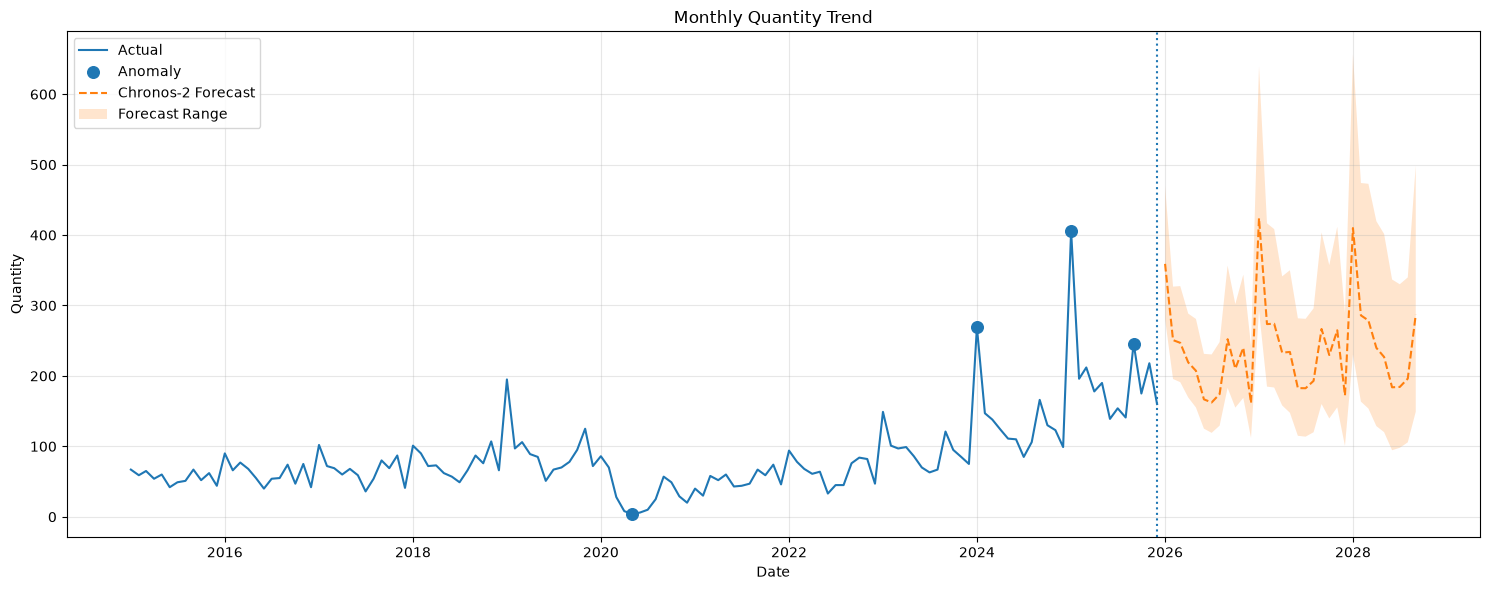

,Anomaly Month,Quantity
64,2020-05-01,4
108,2024-01-01,269
120,2025-01-01,406
128,2025-09-01,246


In [16]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from chronos import Chronos2Pipeline

monthly = (
    df.set_index("transaction_date")
      .resample("MS")["quantity"]
      .sum()
      .reset_index()
)

monthly["anomaly"] = IsolationForest(
    contamination=0.03,
    random_state=42
).fit_predict(monthly[["quantity"]])

anomalies = monthly[monthly["anomaly"] == -1]

context_df = monthly[["transaction_date", "quantity"]].rename(columns={
    "transaction_date": "timestamp",
    "quantity": "target"
})

context_df["id"] = "quantity"
context_df = context_df[["id", "timestamp", "target"]]

prediction_length = round(len(context_df) * 0.25)

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu"
)

forecast_df = pipeline.predict_df(
    context_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target"
)

plt.figure(figsize=(15, 6))

plt.plot(
    monthly["transaction_date"],
    monthly["quantity"],
    label="Actual"
)

plt.scatter(
    anomalies["transaction_date"],
    anomalies["quantity"],
    s=70,
    label="Anomaly",
    zorder=5
)

plt.plot(
    forecast_df["timestamp"],
    forecast_df["predictions"],
    linestyle="--",
    label="Chronos-2 Forecast"
)

plt.fill_between(
    forecast_df["timestamp"],
    forecast_df["0.1"],
    forecast_df["0.9"],
    alpha=0.2,
    label="Forecast Range"
)

plt.axvline(
    monthly["transaction_date"].max(),
    linestyle=":"
)

plt.title("Monthly Quantity Trend")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(
    anomalies[["transaction_date", "quantity"]]
    .rename(columns={
        "transaction_date": "Anomaly Month",
        "quantity": "Quantity"
    })
)

Other Charts

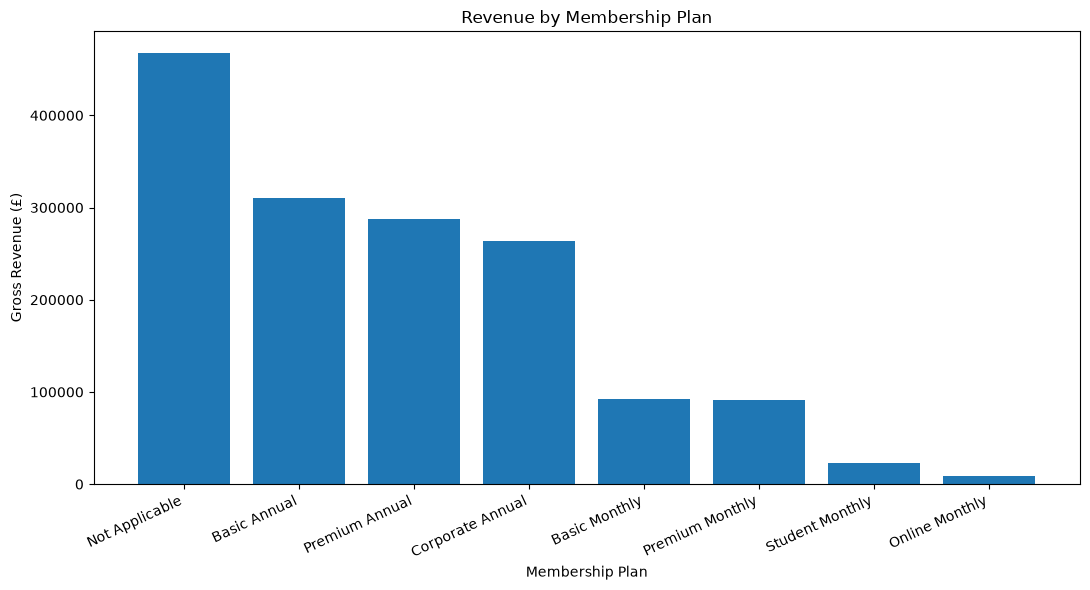

,membership_plan,gross_revenue_gbp
3,Not Applicable,467781.17
0,Basic Annual,310512.12
5,Premium Annual,287076.80
2,Corporate Annual,263744.00
1,Basic Monthly,91962.11
6,Premium Monthly,91035.95
7,Student Monthly,22661.14
4,Online Monthly,8417.84


In [17]:
membership_revenue = (
    df.groupby("membership_plan", as_index=False)["gross_revenue_gbp"]
      .sum()
      .sort_values("gross_revenue_gbp", ascending=False)
)

plt.figure(figsize=(11, 6))
plt.bar(
    membership_revenue["membership_plan"],
    membership_revenue["gross_revenue_gbp"]
)
plt.title("Revenue by Membership Plan")
plt.xlabel("Membership Plan")
plt.ylabel("Gross Revenue (£)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(membership_revenue.round(2))

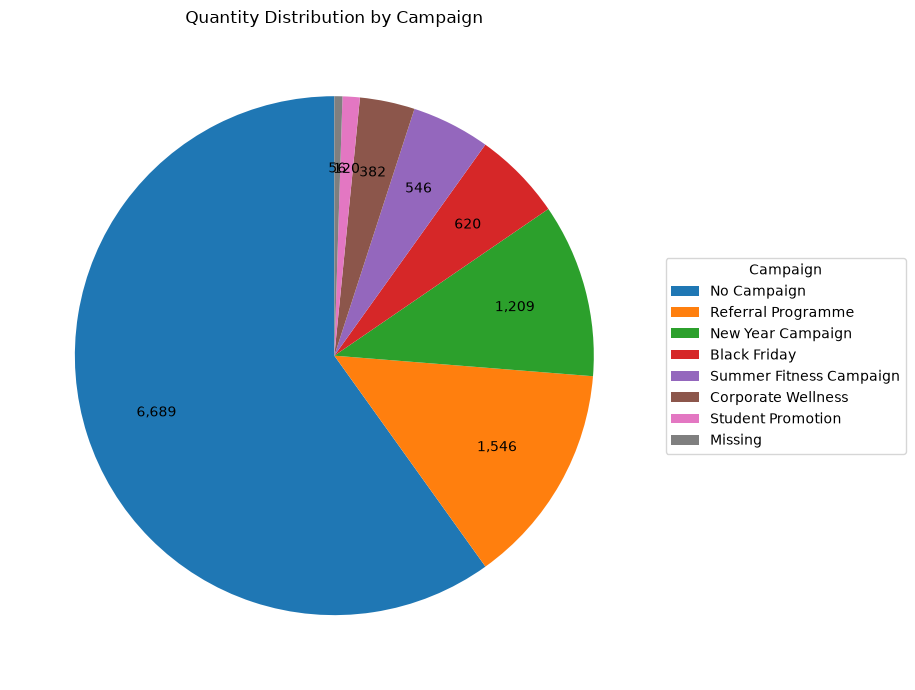

,campaign,quantity
4,No Campaign,6689
5,Referral Programme,1546
3,New Year Campaign,1209
0,Black Friday,620
7,Summer Fitness Campaign,546
1,Corporate Wellness,382
6,Student Promotion,120
2,Missing,56


In [18]:
campaign_quantity = (
    df.assign(campaign=df["campaign"].fillna("Missing"))
      .groupby("campaign", as_index=False)["quantity"]
      .sum()
      .sort_values("quantity", ascending=False)
)

total = campaign_quantity["quantity"].sum()

def show_value(pct):
    value = int(round(pct * total / 100))
    return f"{value:,}"

plt.figure(figsize=(10, 7))

wedges, _, autotexts = plt.pie(
    campaign_quantity["quantity"],
    labels=None,
    autopct=show_value,
    startangle=90,
    pctdistance=0.72
)

plt.legend(
    wedges,
    campaign_quantity["campaign"],
    title="Campaign",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Quantity Distribution by Campaign")
plt.tight_layout()
plt.show()

display(campaign_quantity)

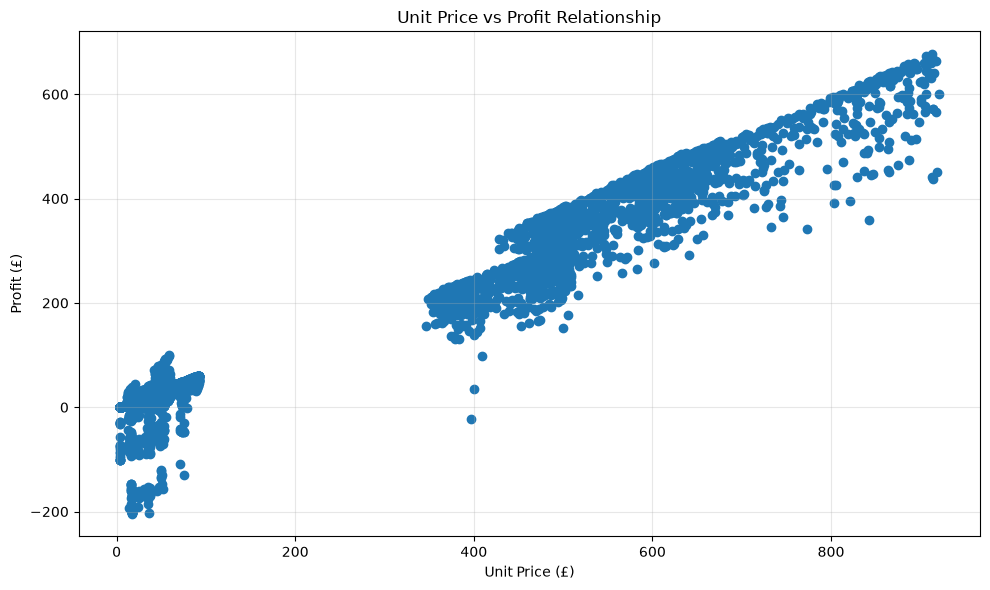

,unit_price_gbp,profit_gbp
0,21.36,5.70
1,474.83,288.43
2,12.03,2.26
3,68.03,34.55
4,15.26,14.91
5,43.23,17.45
6,14.32,10.74
7,3.55,0.14
8,44.10,25.60
9,14.10,2.46


In [19]:
price_profit = df[
    ["unit_price_gbp", "profit_gbp"]
].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    price_profit["unit_price_gbp"],
    price_profit["profit_gbp"]
)

plt.title("Unit Price vs Profit Relationship")
plt.xlabel("Unit Price (£)")
plt.ylabel("Profit (£)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(price_profit.head(10))

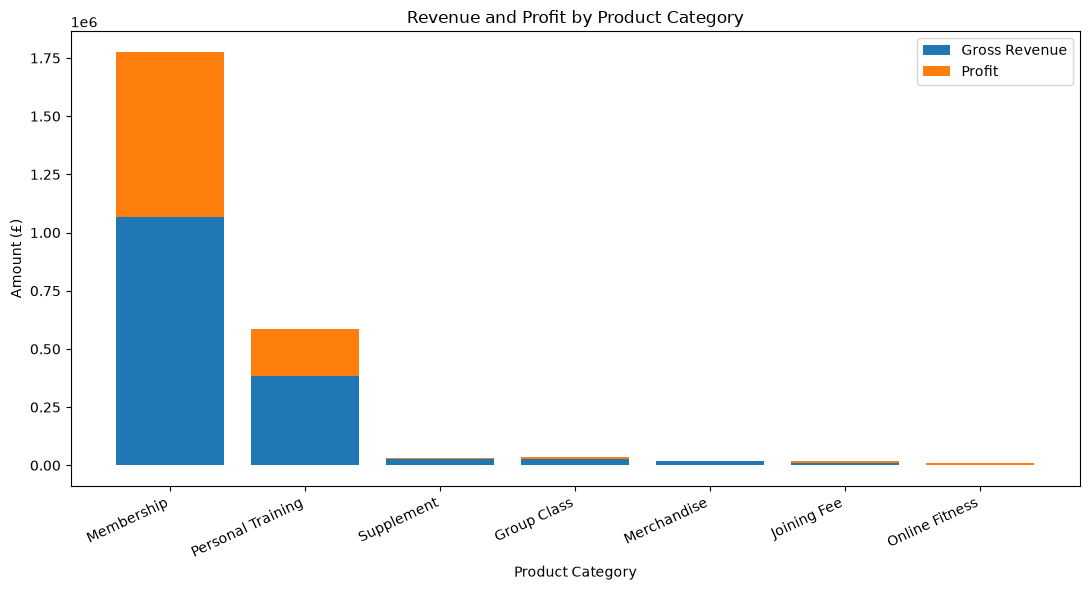

,product_category,Gross_Revenue,Profit
2,Membership,1066992.12,708911.21
5,Personal Training,382283.19,202240.69
6,Supplement,28379.37,1387.18
0,Group Class,28165.84,6995.10
3,Merchandise,17140.93,1780.51
1,Joining Fee,11811.84,6984.57
4,Online Fitness,8417.84,-8745.80


In [20]:
category_financials = (
    df.groupby("product_category", as_index=False)
      .agg(
          Gross_Revenue=("gross_revenue_gbp", "sum"),
          Profit=("profit_gbp", "sum")
      )
      .sort_values("Gross_Revenue", ascending=False)
)

plt.figure(figsize=(11, 6))

plt.bar(
    category_financials["product_category"],
    category_financials["Gross_Revenue"],
    label="Gross Revenue"
)

plt.bar(
    category_financials["product_category"],
    category_financials["Profit"],
    bottom=category_financials["Gross_Revenue"],
    label="Profit"
)

plt.title("Revenue and Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount (£)")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

display(category_financials.round(2))

Insights

In [21]:
quality_check = pd.DataFrame({
    "Metric": ["Missing Values", "Duplicate Rows"],
    "Notebook Value": [
        df.isna().sum().sum(),
        df.duplicated().sum()
    ],
    "Dashboard Value": [80, 0]
})

quality_check["Match"] = (
    quality_check["Notebook Value"]
    == quality_check["Dashboard Value"]
)

display(quality_check)

,Metric,Notebook Value,Dashboard Value,Match
0,Missing Values,80,80,True
1,Duplicate Rows,0,0,True


In [22]:
nov_2025 = df[
    (df["transaction_date"] >= "2025-11-01") &
    (df["transaction_date"] < "2025-12-01")
]

dec_2025 = df[
    (df["transaction_date"] >= "2025-12-01") &
    (df["transaction_date"] < "2026-01-01")
]

def pct_change(current, previous):
    return (current - previous) / previous * 100

gross_change = pct_change(
    dec_2025["gross_revenue_gbp"].sum(),
    nov_2025["gross_revenue_gbp"].sum()
)

quantity_change = pct_change(
    dec_2025["quantity"].sum(),
    nov_2025["quantity"].sum()
)

price_change = pct_change(
    dec_2025["unit_price_gbp"].mean(),
    nov_2025["unit_price_gbp"].mean()
)

nov_margin = (
    nov_2025["profit_gbp"].sum() /
    nov_2025["gross_revenue_gbp"].sum()
)

dec_margin = (
    dec_2025["profit_gbp"].sum() /
    dec_2025["gross_revenue_gbp"].sum()
)

margin_change = pct_change(dec_margin, nov_margin)

anomaly_months = set(
    anomalies["transaction_date"].dt.strftime("%Y-%m")
)

summary_check = pd.DataFrame([
    {
        "Claim": "Gross revenue fell 27.8%",
        "Calculated": f"{gross_change:.1f}%",
        "Reported": "-27.8%",
        "Match": round(gross_change, 1) == -27.8
    },
    {
        "Claim": "Quantity sold dropped 26.6%",
        "Calculated": f"{quantity_change:.1f}%",
        "Reported": "-26.6%",
        "Match": round(quantity_change, 1) == -26.6
    },
    {
        "Claim": "Average unit price fell 6.4%",
        "Calculated": f"{price_change:.1f}%",
        "Reported": "-6.4%",
        "Match": round(price_change, 1) == -6.4
    },
    {
        "Claim": "Profit margin rose 20.7%",
        "Calculated": f"{margin_change:.1f}%",
        "Reported": "+20.7%",
        "Match": round(margin_change, 1) == 20.7
    },
    {
        "Claim": "January 2025 quantity anomaly",
        "Calculated": "Detected" if "2025-01" in anomaly_months else "Not detected",
        "Reported": "Detected",
        "Match": "2025-01" in anomaly_months
    }
])

display(summary_check)

forecast_preview = forecast_df[
    ["timestamp", "predictions", "0.1", "0.9"]
].head(3).copy()

forecast_preview.columns = [
    "Month",
    "Forecast Quantity",
    "Lower Bound",
    "Upper Bound"
]

forecast_preview["Month"] = pd.to_datetime(
    forecast_preview["Month"]
).dt.strftime("%b %Y")

display(forecast_preview.round(2))

,Claim,Calculated,Reported,Match
0,Gross revenue fell 27.8%,-27.8%,-27.8%,True
1,Quantity sold dropped 26.6%,-26.6%,-26.6%,True
2,Average unit price fell 6.4%,-6.4%,-6.4%,True
3,Profit margin rose 20.7%,20.7%,+20.7%,True
4,January 2025 quantity anomaly,Detected,Detected,True


,Month,Forecast Quantity,Lower Bound,Upper Bound
0,Jan 2026,359.109985,280.690002,469.570007
1,Feb 2026,250.860001,195.600006,326.809998
2,Mar 2026,246.990005,191.179993,327.559998
